## Introduction à spaCy

---

### Objectifs de la permanence

**Apprendre à utiliser spaCy et comprendre dans quelle mesure ses fonctionnalités peuvent servir au traitement préliminaire de données textuelles dans le cadre de projets d'Humanités Numériques**

1. Présentation des principales fonctionnalités de spaCy

2. Application de spaCy pour l'analyse de corpus


### Présentation de spaCy

**SpaCy** est une bibliothèque Python Open source largement utilisée pour le **traitement automatique du langage naturel** (TAL/NLP). Elle prend en charge **plus de 70 langues** (liste complète [ici](https://spacy.io/usage/models)) et est conçue pour effectuer diverses tâches plus ou moins complexes, telles que la tokenisation, la lemmatisation, l'étiquetage morphosyntaxique, la reconnaissance d'entités nommées, etc.

Elle en conçue pour être plutôt simple à prendre en main.

![Pipeline](https://spacy.io/images/pipeline.svg)



### Exemples de problématiques HN

Les cas d'utilisation de spaCy en Humanités Numériques peuvent être nombreux. Ci-dessous sont cités quelques exemples :

- Analyse de personnages dans des textes littéraires
- Cartographie des lieux dans les textes
- Analyse de discours médiatiques
- Analyse lexicale et stylistique
- Analyse de représentations culturelles
- etc.


### Exemple d'utilisation

Dans ce notebook, on va utiliser un corpus de **synopsis de films**, récupérés automatiquement sur Wikipédia à partir de leurs URLs. Ce corpus est découpé en 3 catégories, correspondant au **genre** des synopsis de films récupérés :

- **comédie**
- **horreur**
- **documentaire**

Ce corpus nous servira de base pour comprendre comment utiliser spaCy pour l'analyse de corpus textuels.


In [ ]:
# Config Collab
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append("/content/drive/MyDrive/Obtic/Permanences/spaCy") # A adapter selon votre chemin

Mounted at /content/drive


**Installation de spaCy**

In [ ]:
# Installer spaCy (si ce n'est pas déjà fait)
!pip install spacy

In [ ]:
# Télécharger un modèle français (si ce n'est pas déjà fait)
!python3 -m spacy download fr_core_news_sm   # Modèle à adapter selon la langue de votre corpus

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 28.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Importer spaCy
import spacy
from spacy import displacy

**Installation et import des autres librairies utiles au fonctionnement du notebook**

In [ ]:
# Installation
!pip install pandas               # Pour le traitement de corpus
!pip install seaborn              # Pour les visualisations
!pip install matplotlib           # Pour les visualisations
!pip install wordcloud            # Pour les nuages de mots

# Import
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

**Chargement du corpus**

In [ ]:
def load_corpus(data_dir: str) -> pd.DataFrame:
    """Fonction pour charger le corpus"""

    # Initialisation d'une liste vide
    corpus = []

    # Parcourir chaque sous-dossier
    for directory in os.listdir(data_dir):
        directory_path = os.path.join(data_dir, directory)
        if os.path.isdir(directory_path):

            # Lire chaque fichier texte
            for file in os.listdir(directory_path):
                if file.endswith(".txt"):
                    filepath = os.path.join(directory_path, file)
                    with open(filepath, "r", encoding="utf-8") as f:
                        texte = f.read()

                    # Récupération du numéro du synopsis pour l'ID
                    name_without_ext = os.path.splitext(file)[0]
                    number = name_without_ext.split("_")[-1]

                    corpus.append({
                        "ID": f"{directory[:3]}{number}",
                        "genre": directory,
                        "texte": texte
                    })

    return pd.DataFrame(corpus)

_Attention ! Cette fonction de chargement fonctionne pour le corpus utilisé en exemple lors de la permanence. Elle est à **adapter** à vos données !_

In [ ]:
# Chemin vers les données (adapter à vos données)
data_dir = "/content/drive/MyDrive/Obtic/Permanences/spaCy/data"

# Charger et afficher le corpus
corpus = load_corpus(data_dir)
corpus

,ID,genre,texte
0,doc47,documentaire,"D'anciens ouvriers et ouvrières d'Amisol, usin..."
1,doc48,documentaire,Ce film est un re critique de la société améri...
2,doc99,documentaire,"Roberto Minervini va en Louisiane et au Texas,..."
3,doc39,documentaire,Le film retrace le parcours des députés Franço...
4,doc50,documentaire,Simon a 7 ans. Un mystérieux ballon rouge le s...
...,...,...,...
303,com23,comedie,Jean Renault est un n qui a autrefois remporté...
304,com88,comedie,"Pierre Brochant, célèbre éditeur parisien, org..."
305,com90,comedie,Charlie Baileygates est motard au sein de la p...
306,com3,comedie,Yacine quitte son Maroc natal pour aller étudi...


In [ ]:
# Vérifier le nombre de fichiers
corpus["genre"].value_counts()

,count
genre,
documentaire,107
comedie,101
horreur,100



### 1. Présentation des principales fonctionnalités de spaCy

On va commencer par tester spaCy sur un seul texte. On appliquera ses fonctionnalités sur tout le corpus dans une second temps.

In [ ]:
# Extraction du premier synopsis de Horreur
texte = corpus[corpus["ID"] == "hor1"]["texte"].iloc[0]
print(texte)

Pendant l'été du 1er juillet 1974, sur l'île d'Amity, un groupe d'étudiants fait la fête sur la plage. Une jeune femme s'éloigne du groupe pour un bain de minuit alors que son flirt s'endort sur la plage, ivre. Après quelques brasses, la jeune femme est attaquée par une force mystérieuse, elle tente de résister mais est happée et disparaît dans l'eau en poussant des cris de terreur. Quelques secondes après, la mer retrouve son calme nocturne. Personne ne sait ce qui vient de se dérouler. Le lendemain, à la suite de la déclaration de la disparition de la jeune femme, Martin Brody, nouveau chef de la police locale originaire de New York, découvre les restes de la victime. Il attribue aussitôt cette mort à une attaque de requin, mais sous la pression du conseil municipal et aussi en raison de son inexpérience sur cette île, il suit les recommandations du médecin légiste de l'île et conclut à une mort accidentelle (noyade et choc avec un bateau). Quelques jours après, un enfant est happé à

#### a) Fonctionnalités basiques

- **Traitement du texte avec spaCy**

La première étape lorsque l'on souhaite traiter du texte automatiquement avec spaCy, est de charger le modèle de la langue de notre corpus et de l'appliquer au corpus.

In [ ]:
# Charger le modèle français
nlp = spacy.load('fr_core_news_sm')

# Traiter le texte avec spaCy
doc = nlp(texte)

Lors du traitement (quand on fait `doc = nlp(texte)`), spaCy commence par **tokeniser** le texte.

La **tokenisation** est l'une des premières étapes du traitement de texte. Elle consiste à diviser un texte en unités appelées "_tokens_", qui peuvent être des mots, des parties de mots ou même des caractères.

<img src="https://miro.medium.com/v2/resize:fit:828/format:webp/1*EmXiN_xslbFyBmvxCT_vpw.png" alt="Tokenisation" width="500">


Bien que les mots en français ou en anglais soient généralement séparés par des espaces, cela ne suffit pas toujours. Par exemple, des expressions comme "_pomme de terre_", "_New York_" ou "_rock n' roll_" peuvent être traitées comme des entités uniques malgré les espaces qu'elles contiennent. À l'inverse, des contractions comme "_I'm_" doivent être divisées en deux tokens : "_I_" et "_am_". La tokenisation est cruciale car la plupart des analyses linguistiques nécessitent des données segmentées de manière cohérente. (**Source :** _[Pandore Toolbox](https://obtic-gpu1.mesu.sorbonne-universite.fr/pandore/documentation_preprocessing)_)

Avec spaCy, la tokenisation est effectuée en appliquant des règles spécifiques à chaque langue. Il est donc important de bien sélectionner le modèle de traitement de la langue de notre corpus ! Dans notre cas, on a choisi le modèle `fr_core_news_sm` puisque notre corpus est en français. Ce modèle a été entraîné sur le corpus [UD French-Sequoia](https://github.com/UniversalDependencies/UD_French-Sequoia) et le corpus [WikiNER](https://figshare.com/articles/dataset/Learning_multilingual_named_entity_recognition_from_Wikipedia/5462500).

Après application du modèle à notre phrase, les tokens sont stockés dans dans l'objet `doc` et on peut itérer dessus comme ceci :

In [ ]:
for token in doc[:10]:
    print(f"{token.text}")

Pendant
l'
été
du
1er
juillet
1974
,
sur
l'


- **Segmentation en phrases**

En plus des tokens stockés dans notre objet `doc`, le traitement du texte rend également possible la segmentation en phrases. On y accède avec l'attribut `sents`.

In [ ]:
# Segmentation en phrases
sentences = []
for sent in doc.sents:
    sentences.append(sent)

# Affichage des 10 premières
for sent in sentences[:10]:
    print(sent.text)
    print("---")

Pendant l'été du 1er juillet 1974, sur l'île d'Amity, un groupe d'étudiants fait la fête sur la plage.
---
Une jeune femme s'éloigne du groupe pour un bain de minuit alors que son flirt s'endort sur la plage, ivre.
---
Après quelques brasses, la jeune femme est attaquée par une force mystérieuse, elle tente de résister mais est happée et disparaît dans l'eau en poussant des cris de terreur.
---
Quelques secondes après, la mer retrouve son calme nocturne.
---
Personne ne sait ce qui vient de se dérouler.
---
Le lendemain, à la suite de la déclaration de la disparition de la jeune femme, Martin Brody, nouveau chef de la police locale originaire de New York, découvre les restes de la victime.
---
Il attribue aussitôt cette mort à une attaque de requin, mais sous la pression du conseil municipal et aussi en raison de son inexpérience sur cette île, il suit les recommandations du médecin légiste de l'île et conclut à une mort accidentelle (noyade et choc avec un bateau).
---
Quelques jours 

Pour nos premiers exemples de démonstration des fonctionnalités de spaCy, on va commencer sur une seule phrase pour une meilleure visualisation.

In [ ]:
# Extraction de la première phrase uniquement
sentence = sentences[0]
print(sentence)

Pendant l'été du 1er juillet 1974, sur l'île d'Amity, un groupe d'étudiants fait la fête sur la plage.


- **Lemmatisation**

Comme on l'a vu, le traitement du texte par spaCy permet de découper un texte en une séquence de tokens. Mais ce n'est pas tout ! A chacun de ces tokens sont automatiquement attribués des propriétés linguistiques. Pour chaque token, on peut ainsi accéder par exemple à son lemme. C'est ce qu'on appelle la **lemmatisation**.

<img src="https://miro.medium.com/v2/resize:fit:640/format:webp/1*A5YJhglv0NXW9kNJBA0-8w.jpeg" alt="Lemmatisation" width="400">

Il s'agit d'une composante importante de la **normalisation**, qui vise à réduire les mots à leur **forme de base ou '_lemme_'**. Cela permet de regrouper différentes formes d'un même mot sous une seule représentation. Par exemple, "_sang_", "_sung_" et "_sings_" en anglais sont toutes des variantes du verbe "_sing_" et seront ramenées à cette forme canonique. La lemmatisation est particulièrement utile pour réduire la complexité lexicale, améliorer la généralisation et obtenir des analyses plus précises dans des tâches comme la recherche ou la classification. (**Source :** _[Pandore Toolbox](https://obtic-gpu1.mesu.sorbonne-universite.fr/pandore/documentation_preprocessing)_)

Avec spaCy, on accède à cette forme canonique avec l'attribut `lemma_` (Attention à ne pas oublier l'_underscore_ !)

In [ ]:
# Lemmatisation
for token in sentence:
    print(f"{token.text} → {token.lemma_}")

Pendant → pendant
l' → le
été → été
du → de
1er → premier
juillet → juillet
1974 → 1974
, → ,
sur → sur
l' → le
île → île
d' → de
Amity → Amity
, → ,
un → un
groupe → groupe
d' → de
étudiants → étudiant
fait → faire
la → le
fête → fête
sur → sur
la → le
plage → plage
. → .


- **Etiquetage morphosyntaxique (_POS-tagging_)**

Une autre fonctionnalité de spaCy et que l'on utilise TRES souvent en NLP, est l'**étiquetage morphosyntaxique** (ou _POS-tagging_). C'est, comme son nom l'indique, l'attribution des catégories morphosyntaxiques à chaque token. On peut accéder à cette étiquette en utilisant l'attribut `pos_`.

<img src="https://miro.medium.com/v2/resize:fit:828/format:webp/1*qZELwIpKeEQ-j3EnRF-CrQ.jpeg" alt="POS-tagging" width="500">


In [ ]:
# POS-tagging
for token in sentence:
    print(f"{token.text} → {token.pos_}")

Pendant → ADP
l' → DET
été → NOUN
du → ADP
1er → ADJ
juillet → NOUN
1974 → NUM
, → PUNCT
sur → ADP
l' → DET
île → NOUN
d' → ADP
Amity → PROPN
, → PUNCT
un → DET
groupe → NOUN
d' → ADP
étudiants → NOUN
fait → VERB
la → DET
fête → NOUN
sur → ADP
la → DET
plage → NOUN
. → PUNCT


Cet étiquetage fournit une analyse linguistique détaillée qui peut être utilisée dans diverses applications :

- **Comparaison de traductions et éditions :** Identifier les différences entre deux versions d'un même texte, notamment au niveau grammatical.
- **Filtrage de termes :** Extraire les verbes, noms propres ou toute autre catégorie pour des analyses spécifiques.
- **Prétraitement pour des tâches complexes :** Les modèles avancés comme ceux de traduction automatique ou d'analyse sémantique dépendent fortement de cette catégorisation.

(**Source :** _[Pandore Toolbox](https://obtic-gpu1.mesu.sorbonne-universite.fr/pandore/documentation_annotation)_)

- **Analyse morphologique**

SpaCy fournit, en plus de l'annotation morphosyntaxique, des informations sur la **morphologie** des tokens. Ces informations sont stockées dans l'attribut `morph`.

In [ ]:
# Morphologie
for token in sentence:
    print(f"{token.text} → {token.morph}")

Pendant → 
l' → Definite=Def|Number=Sing|PronType=Art
été → Gender=Masc|Number=Sing
du → Definite=Def|Gender=Masc|Number=Sing|PronType=Art
1er → NumType=Ord
juillet → Gender=Masc|Number=Sing
1974 → NumType=Card
, → 
sur → 
l' → Definite=Def|Number=Sing|PronType=Art
île → Gender=Masc|Number=Sing
d' → 
Amity → Gender=Masc|Number=Sing
, → 
un → Definite=Ind|Gender=Masc|Number=Sing|PronType=Art
groupe → Gender=Masc|Number=Sing
d' → 
étudiants → Gender=Masc|Number=Plur
fait → Gender=Masc|Number=Sing|Tense=Past|VerbForm=Part
la → Definite=Def|Gender=Fem|Number=Sing|PronType=Art
fête → Gender=Fem|Number=Sing
sur → 
la → Definite=Def|Gender=Fem|Number=Sing|PronType=Art
plage → Gender=Masc|Number=Sing
. → 


**Remarque :** Attention ! Il ne faut pas prendre pour argent comptant toutes les annotations fournies par spaCy. Les annotations sont prédies par des modèles statistiques entraînés sur des corpus et ne constituent pas une vérité générale. L'outil fait des erreurs, après c'est à nous de décider à quel point on estime ces erreurs acceptables.

Par exemple, le modèle `fr_core_news_sm` qu'on a utilisé dans les exemples précédents possède des performances différentes selon les tâches.

*Accuracy* (exactitude) :

- Tokenization : 1.00
- POS-tagging : 0.99
- Morphologie : 0.98
- Lemmatisation : 0.92
- Segmentation en phrases (F-score) : 0.93

Plus d'infos [ici](https://spacy.io/models/fr)

#### b) Fonctionnalités avancées

Maintenant qu'on a vu les principales fonctionnalités de base de spaCy, on va juste voir 3 fonctionnalités un peu plus avancées, avant de passer à la mise en pratique.

- **Syntaxe en dépendance (_Dependency parsing_)**

SpaCy permet de détreminer la structure syntaxique des phrases, en fournissant une **analyse en dépendances**, c'est-à-dire que chaque token de la phrase a un gouverneur unique (sa **tête**) par lequel il est relié par une relation de dépendance.

<img src="https://spacy.io/images/displacy.svg" alt="Dependency parsing" width="600">


Ainsi, pour chaque token, on peut accéder à son gouverneur syntaxique (le token dont il dépend) avec l'attribut `head`, ainsi qu'à sa relation de dépendance avec son gouverneur avec l'attribut `dep`. La **racine** de la phrase (généralement le verbe) est annoté _ROOT_ et a pour tête lui-même.

In [ ]:
# Syntaxe en dépendance
for token in sentence:
    print(f"{token.text} → {token.dep_} ({token.head})")

Pendant → case (été)
l' → det (été)
été → obl:mod (fait)
du → case (1er)
1er → nmod (été)
juillet → nmod (1er)
1974 → nmod (juillet)
, → punct (été)
sur → case (île)
l' → det (île)
île → obl:mod (fait)
d' → case (Amity)
Amity → nmod (île)
, → punct (île)
un → det (groupe)
groupe → nsubj (fait)
d' → case (étudiants)
étudiants → nmod (groupe)
fait → ROOT (fait)
la → det (fête)
fête → obj (fait)
sur → case (plage)
la → det (plage)
plage → nmod (fête)
. → punct (fait)


La structure produite par l'analyse syntaxique est un **arbre** dont

- les **noeuds** sont les tokens
- les **arcs** les relations de dépendances.

Cette structure n'est pas super intuitive quand on observe le résultat précédent. C'est pourquoi le module `displacy` permet de visualiser cette structure arborée !

In [ ]:
# Visualisation
displacy.render(sentence, style='dep', jupyter=True, options={'distance':140})

On peut également utiliser divers attributs pour parcourir cet arbre de dépendances :

- `subtree` : tous les descendants (directs ou non) d'un token
- `children` : tous les enfants (descendants directs) d'un token
- `rights` : tous les enfants à droite d'un token
- `lefts` : tous les enfants à gauche d'un token
- `ancestors` : tous les ancêtres d'un token

In [ ]:
# Exemple avec "fête" comme token
ref_token = [token for token in sentence if token.text == "fête"][0]

# Descendants
print(f"Descendants de \"{ref_token}\" : {list(ref_token.subtree)}")

# Enfant
print(f"Enfants de \"{ref_token}\" : {list(ref_token.children)}")

# Enfants à droite
print(f"Enfants à droite de \"{ref_token}\" : {list(ref_token.rights)}")

# Enfants à gauche
print(f"Enfants à gauche de \"{ref_token}\" : {list(ref_token.lefts)}")

# Ancêtres
print(f"Parents de \"{ref_token}\" : {list(ref_token.ancestors)}")


Descendants de "fête" : [la, fête, sur, la, plage]
Enfants de "fête" : [la, plage]
Enfants à droite de "fête" : [plage]
Enfants à gauche de "fête" : [la]
Parents de "fête" : [fait]


On peut par exemple utiliser ces propriétés pour reconstituer la structure globale de la phrase (sujet, verbe, objet).

In [ ]:
# Extraction de la racine
root = [token for token in sentence if token.head == token][0]

# Extraction du sujet
sujet = [token for token in root.children if token.dep_ == "nsubj"][0]

# Extraction de l'objet
objet = [token for token in root.children if token.dep_ == "obj"][0]

# Affichage
print(f"{sujet} (S), {root} (V), {objet}(O)")


groupe (S), fait (V), fête(O)


- **Détection des mots-vides (_stopwords_)**

Les mots-vides (ou _stopwords_) sont des mots qui ne sont pas porteurs d'une grande information sémantique. Ce sont généralement les mots grammticaux comme _de_, _qui_, _le_, etc. L'attribut `is_stop` permet de détecter ces mots.

<img src="https://repository-images.githubusercontent.com/70948862/f8d8f380-beb0-11e9-8f03-050093c4220c" alt="Stopwords" width="500">

La suppression des stopwords est une technique couramment utilisée pour limiter le **bruit** dans les tâches d'analyse textuelle. Ces mots, bien qu'indispensables à la construction grammaticale, apportent peu de valeur sémantique et risquent d'alourdir les analyses. En les éliminant, on peut non seulement simplifier les représentations textuelles, mais aussi optimiser la taille des structures de données. Cela permet de focaliser les efforts de traitement sur les termes porteurs de sens et d'améliorer la pertinence des résultats. (Source : _[Pandore Toolbox](https://obtic-gpu1.mesu.sorbonne-universite.fr/pandore/documentation_preprocessing)_)

In [ ]:
# Détection des stopwords
print(sentence)
for token in sentence:
    if token.is_stop:
        print(f"{token.text}")

Pendant l'été du 1er juillet 1974, sur l'île d'Amity, un groupe d'étudiants fait la fête sur la plage.
Pendant
l'
du
sur
l'
d'
un
d'
fait
la
fête
sur
la
plage


Et on peut-même ajouter ses propres _stopwords_ !

Admettons que (je ne sais pour quelle raison) on veuille considérer les mots "_fête_" et "_plage_" comme des mots-vides. Il nous suffit de les ajouter à la liste des _stopword_ et de traiter à nouveau la phrase :

In [ ]:
# Fonction d'ajout de stopwords
def add_stopwords(nlp, liste):
    for mot in liste:
        nlp.Defaults.stop_words.add(mot)
        nlp.vocab[mot].is_stop = True
    return nlp

# Liste des mots à ajouter aux stopwords
liste = [
    "fête",
    "plage"
]

# Ajout
new_nlp = add_stopwords(nlp, liste)

# Application du nouveau modèle à la phrase
new_sentence = new_nlp(sentence.text)

# Affichage
for token in new_sentence:
    if token.is_stop:
        print(f"{token.text}")

Pendant
l'
du
sur
l'
d'
un
d'
fait
la
fête
sur
la
plage


- **Reconnaissance d'entités nommées (NER)**

La reconnaissance des entités nommées (REN), ou _Named Entity Recognition_ (NER) en anglais, est une tâche clé du traitement automatique du langage naturel (NLP). Elle consiste à identifier dans un texte des portions spécifiques qui correspondent à des entités et à leur attribuer un type particulier. Une entité nommée, de manière générale, désigne tout élément qui peut être référencé par un nom propre, comme une personne, un lieu ou une organisation. Cependant, le concept d'entité nommée peut être élargi pour inclure des dates, des expressions temporelles, des prix ou d'autres formes d'expressions numériques.

<img src="https://miro.medium.com/v2/resize:fit:828/format:webp/1*25pE_3FRfkkABhcFR2UAcA.png" alt="Stopwords" width="600">

La REN est utilisée dans de nombreux domaines et applications :

- **Extraction d'information :** Identifier automatiquement des informations clés dans de vastes volumes de données, comme les noms des intervenants dans un texte ou les lieux d'un événement.
- **Systèmes de recherche d'information :** Améliorer la recherche documentaire en focalisant sur les entités nommées plutôt que sur des mots-clés généraux.
- **Analyse de sentiments :** Examiner les opinions ou sentiments associés à des entités spécifiques.
- **Traduction automatique :** Reconnaître et traduire correctement les noms propres ou entités spécifiques d'un texte source vers une langue cible.
- **Reconnaissance vocale :** Mieux interpréter les noms propres ou termes uniques dans les commandes vocales.

(Source : _[Pandore Toolbox](https://obtic-gpu1.mesu.sorbonne-universite.fr/pandore/documentation_annotation)_)

SpaCy intègre une fonctionnalité de NER. Les entités sont stockées dans l'attribut `ents`.

In [ ]:
# NER
print(sentence)
for ent in sentence.ents:
    print(f"{ent} → {ent.label_}")

Pendant l'été du 1er juillet 1974, sur l'île d'Amity, un groupe d'étudiants fait la fête sur la plage.
île d'Amity → LOC


Le module `displacy` permet de mieux visualiser l'annotation des entités nommées dans des textes longs.

In [ ]:
displacy.render(sentence, style="ent", jupyter=True)

Et de la même façon que spaCy permet d'ajouter sa propre liste de mots-vides, on peut également ajouter ses propres entités nommées avec leurs propres labels, ce qui est souvent utile dans le traitement de corpus spécialisés, comme les textes médicaux.

In [ ]:
from spacy.pipeline import EntityRuler

# Fonction d'ajout d'entités nommées
def add_entities(dico):
    nlp = spacy.blank("fr")
    ruler = nlp.add_pipe("entity_ruler")
    patterns = [
        {"label": label, "pattern": mot}
        for mot, label in dico.items()
    ]
    ruler.add_patterns(patterns)
    return nlp

# Exemple
notice_doliprane = "Ce médicament est un antalgique et un antipyrétique qui contient du paracétamol.\nIl est utilisé pour faire baisser la fièvre et dans le traitement des affections douloureuses."

# Dictionnaire des entités à ajouter
dico_entites = {
    "antalgique": "TYPE",
    "antipyrétique": "TYPE",
    "paracétamol": "MOL",
    "fièvre": "SYMP",
    "affections douloureuses": "SYMP"
}

# Ajout
new_nlp = add_entities(dico_entites)

# Application du nouveau modèle à la phrase
notice_annotee = new_nlp(notice_doliprane)
displacy.render(notice_annotee, style="ent", jupyter=True)

### Résumé des principales fonctionnalités de spaCy

#### **1. Préréquis**

- Installer spaCy

```
!pip install spacy
```

- Installer un modèle dans la langue du corpus (ici français)

```
!python3 -m spacy download fr_core_news_sm
```

- Importer spaCy (et displaCy pour visualisation)

```
import spacy
from spacy import displacy
```

- Traitement du texte avec spaCy

```
# Charger le modèle téléchargé
nlp = spacy.load('fr_core_news_sm')

# Traiter le texte avec spaCy
doc = nlp(texte)
```

#### **2. Tâches**

- Segmentation en phrases

```
for sent in doc.sents:
    print(sent.text)
```

- Tokenisation

```
for token in doc:
    print(token.text)
```

- Lemmatisation

```
for token in doc:
    print(token.lemma_)
```

- Pos-tagging

```
for token in doc:
    print(token.pos_)
```

- Morphologie

```
for token in doc:
    print(token.morph)
```

- Syntaxe en dépendance

```
for token in sentence:
    print(f"{token.text} → {token.dep_} ({token.head})")

displacy.render(sentence, style='dep', jupyter=True)
```

- Détection des stopwords

```
for token in sentence:
    if token.is_stop:
        print(token.text)
```

- Reconnaissance d'Entités Nommées

```
for ent in sentence.ents:
    print(f"{ent} → {ent.label_}")
    
displacy.render(sentence, style="ent", jupyter=True)
```



### 2. Application de spaCy pour l'analyse de corpus

Maintenant qu'on a vu les principales fonctionnalités de spaCy, on va les utiliser pour mener une analyse textuelle **comparative** sur notre corpus, afin de mieux comprendre les utilisations concrètes de l'outil.

Pour cela, on va utiliser notre corpus de synopsis chargé au tout début du notebook et tenter de répondre à des questions dont l'objectif sera d'en apprendre un peu plus sur notre corpus, sans avoir à tout lire et tout analyser à la main (_distant reading_).

In [ ]:
corpus

,ID,genre,texte
0,doc47,documentaire,"D'anciens ouvriers et ouvrières d'Amisol, usin..."
1,doc48,documentaire,Ce film est un re critique de la société améri...
2,doc99,documentaire,"Roberto Minervini va en Louisiane et au Texas,..."
3,doc39,documentaire,Le film retrace le parcours des députés Franço...
4,doc50,documentaire,Simon a 7 ans. Un mystérieux ballon rouge le s...
...,...,...,...
303,com23,comedie,Jean Renault est un n qui a autrefois remporté...
304,com88,comedie,"Pierre Brochant, célèbre éditeur parisien, org..."
305,com90,comedie,Charlie Baileygates est motard au sein de la p...
306,com3,comedie,Yacine quitte son Maroc natal pour aller étudi...


- **Nombre de mots selon le genre**

Une première question que l'on peut se poser sur notre corpus est la variabilité du nombre de mots selon le genre.

> Par exemple, est-ce que les synopsis de documentaires sont globalement plus longs que les synopsis de films d'horreur ?



In [ ]:
def count_words(text):
    doc = nlp(text)
    nb_words = 0
    for token in doc:
        if not token.is_punct and not token.is_space and token.lemma_.strip() != '': # Suppression des ponctuations
            nb_words += 1
    return nb_words

corpus["nb_mots"] = corpus["texte"].astype(str).apply(count_words)

corpus

,ID,genre,texte,nb_mots
0,doc47,documentaire,"D'anciens ouvriers et ouvrières d'Amisol, usin...",161
1,doc48,documentaire,Ce film est un re critique de la société améri...,145
2,doc99,documentaire,"Roberto Minervini va en Louisiane et au Texas,...",124
3,doc39,documentaire,Le film retrace le parcours des députés Franço...,64
4,doc50,documentaire,Simon a 7 ans. Un mystérieux ballon rouge le s...,54
...,...,...,...,...
303,com23,comedie,Jean Renault est un n qui a autrefois remporté...,104
304,com88,comedie,"Pierre Brochant, célèbre éditeur parisien, org...",1616
305,com90,comedie,Charlie Baileygates est motard au sein de la p...,163
306,com3,comedie,Yacine quitte son Maroc natal pour aller étudi...,238


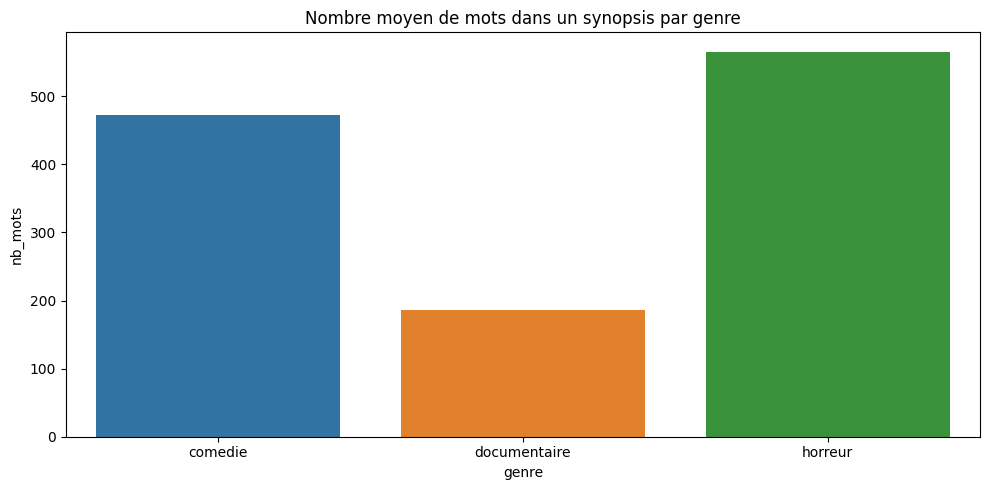

In [ ]:
# Visualisation
def draw_graph_by_genre(corpus, col, title):
    """Trace le graphique de comparaison de la colonne choisie par genre"""

    # Ordre des genres à afficher
    genre_order = sorted(corpus["genre"].unique())

    # Palette associée à cet ordre
    colors = sns.color_palette("tab10", len(genre_order))
    palette_genre = dict(zip(genre_order, colors))

    # Calcul de la valeur moyenne par genre
    mean_value = (
        corpus.groupby("genre")[col]
        .mean()
        .reindex(genre_order)
        .reset_index()
    )

    # Tracé du graphique
    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=mean_value,
        x="genre",
        y=col,
        hue="genre",
        order=genre_order,
        palette=palette_genre,
        legend=False
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

draw_graph_by_genre(corpus, col="nb_mots", title="Nombre moyen de mots dans un synopsis par genre")

Ici, on peut largement invalider notre hypothèse selon laquelle les synopsis de documentaires seraient plus longs que ceux des films d'horreur. On observe qu'en terme de nombre de mots, les synopsis des documentaires sont significativement plus courts que ceux des films d'horreur et des comédies.

- **Nombre de phrases selon le genre**

Une information avec laquelle on peut essayer de croiser le nombre moyen de mots est le nombre moyen de phrases selon le genre. En effet, on voit que les synopsis de comédie ne sont que légèrement plus courts que ceux des films d'horreur. Or, une question que l'on peut se poser est

> Est-ce que cette tendance s'observe également au niveau du nombre de phrases ?

Cela peut éventuellement nous donner des indices sur le **_rythme_** des textes. Par exemple, un texte avec un nombre important de mots mais un nombre faible de phrases suggère des phrases longues et donc plus ou moins complexes, alors qu'à l'inverse, un texte avec un nombre moyen de mots mais un nombre élevé de phrases suggèrerait plutôt des phrases courtes et un rythme plus _saccadé_.

Ce type de questionnement peut notamment être utile dans des analyses comparatives de **poésies**, de répliques de personnages dans des pièces de **théâtre** etc.

Bien évidemment, ces observations restent de l'ordre du **_distant reading_**. Elles ne dispensent donc pas d'une analyse et d'une interprétation humaine mais permettent d'orienter les hypothèses et de dégager certaines tendances.

In [ ]:
def count_sentences(text):
    doc = nlp(text)
    nb_sentences = 0
    for sent in doc.sents:
        nb_sentences += 1
    return nb_sentences

corpus["nb_phrases"] = corpus["texte"].astype(str).apply(count_sentences)

corpus

,ID,genre,texte,nb_mots,nb_phrases
0,doc47,documentaire,"D'anciens ouvriers et ouvrières d'Amisol, usin...",161,7
1,doc48,documentaire,Ce film est un re critique de la société améri...,145,7
2,doc99,documentaire,"Roberto Minervini va en Louisiane et au Texas,...",124,4
3,doc39,documentaire,Le film retrace le parcours des députés Franço...,64,1
4,doc50,documentaire,Simon a 7 ans. Un mystérieux ballon rouge le s...,54,4
...,...,...,...,...,...
303,com23,comedie,Jean Renault est un n qui a autrefois remporté...,104,3
304,com88,comedie,"Pierre Brochant, célèbre éditeur parisien, org...",1616,61
305,com90,comedie,Charlie Baileygates est motard au sein de la p...,163,7
306,com3,comedie,Yacine quitte son Maroc natal pour aller étudi...,238,9


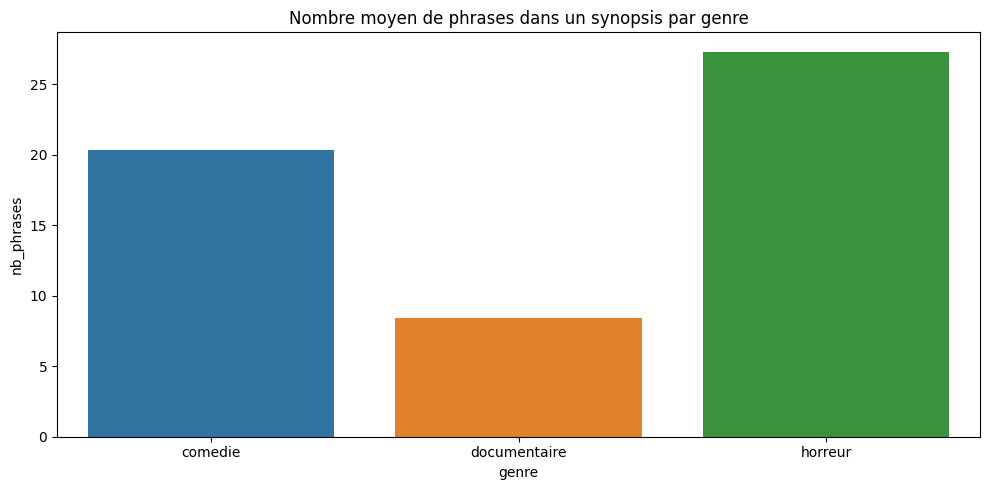

In [ ]:
# Visualisation
draw_graph_by_genre(corpus, col="nb_phrases", title="Nombre moyen de phrases dans un synopsis par genre")

Dans notre corpus, on observe que le nombre moyen de mots et le nombre moyen de phrases ont une distribution similaire selon les genres. On ne peut donc pas tirer de conclusion quant au _rythme_ des textes selon les genres.

En effet, quand on observe le nombre moyen de mots par phrases, on n'observe pas de différence significative en fonction du genre :

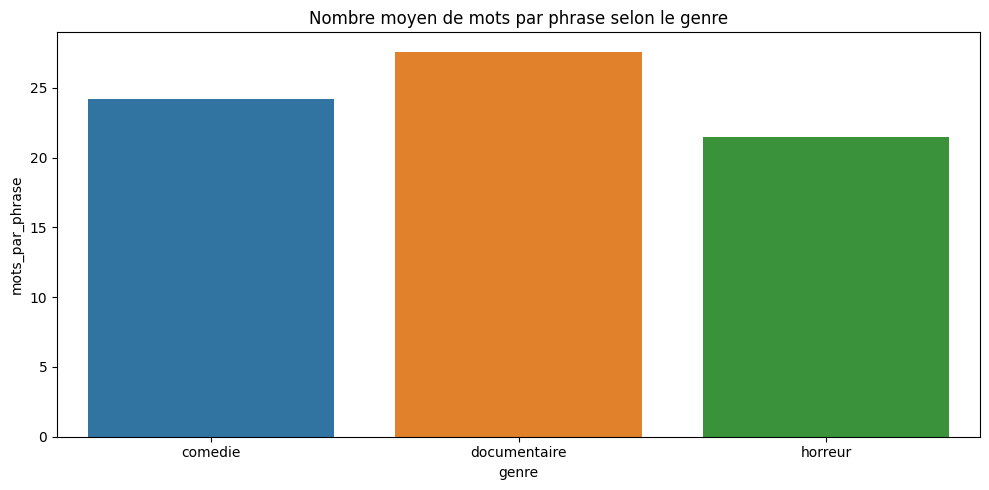

In [ ]:
corpus["mots_par_phrase"] = (corpus["nb_mots"] / corpus["nb_phrases"]).round(0).astype(int)
draw_graph_by_genre(corpus, col="mots_par_phrase", title="Nombre moyen de mots par phrase selon le genre")

- **Mots les plus fréquents par genre**

Pour l'instant, on s'est intéressé à des métriques assez basiques et donnant une vision plutôt large des textes de notre corpus. On va maintenant utiliser une analyse plus fine, qui consiste à identifier les mots les plus fréquents selon les genres afin d'en apprendre un peu plus sur nos textes.

Cette tâche est utilisée pour identifier de façon simple et basique les **thèmes récurrents** dans un corpus et permet d'avoir une vision globale de ce dont un corpus parle. On va pour cela utiliser deux représentations.

In [ ]:
# 1. Lemmatiser les textes
def get_lemmas(text):
    doc = nlp(text.lower())
    lemmes = []
    for token in doc:
        if not token.is_stop and not token.is_punct and token.lemma_.strip() != '': # Suppression des stopwords et de la ponctuation
            lemmes.append(token.lemma_)
    return lemmes

corpus["lemmes"] = corpus["texte"].astype(str).apply(get_lemmas)


# 2. Compter le nombre d'apparitions des lemmes pour chaque genre
def count_occ_by_genre(corpus, col):
    """Compte le nombre d'occurrences d'une unité (col) par genre"""

    # Compter le nombre d'apparition des lemmes pour chaque genre
    occ_by_genre = {}
    for genre, group in corpus.groupby("genre"):
        all_occ = [occ for occurrences in group[col] for occ in occurrences]
        occ_by_genre[genre] = Counter(all_occ)

    # Traitement pour affichage
    most_frequent_occ = []
    for genre, counter in occ_by_genre.items():
        for occ, freq in counter.items():
            most_frequent_occ.append({
                "genre": genre,
                col: occ,
                "frequence": freq
            })

    return pd.DataFrame(most_frequent_occ)

most_freq_lemmas = count_occ_by_genre(corpus, col="lemmes")
most_freq_lemmas.head(10)

,genre,lemmes,frequence
0,comedie,tonnerre,3
1,comedie,tropique,2
2,comedie,livre,9
3,comedie,john,3
4,comedie,feuill,2
5,comedie,trèfle,2
6,comedie,tayback,6
7,comedie,vétéran,2
8,comedie,guerre,8
9,comedie,viêt,1


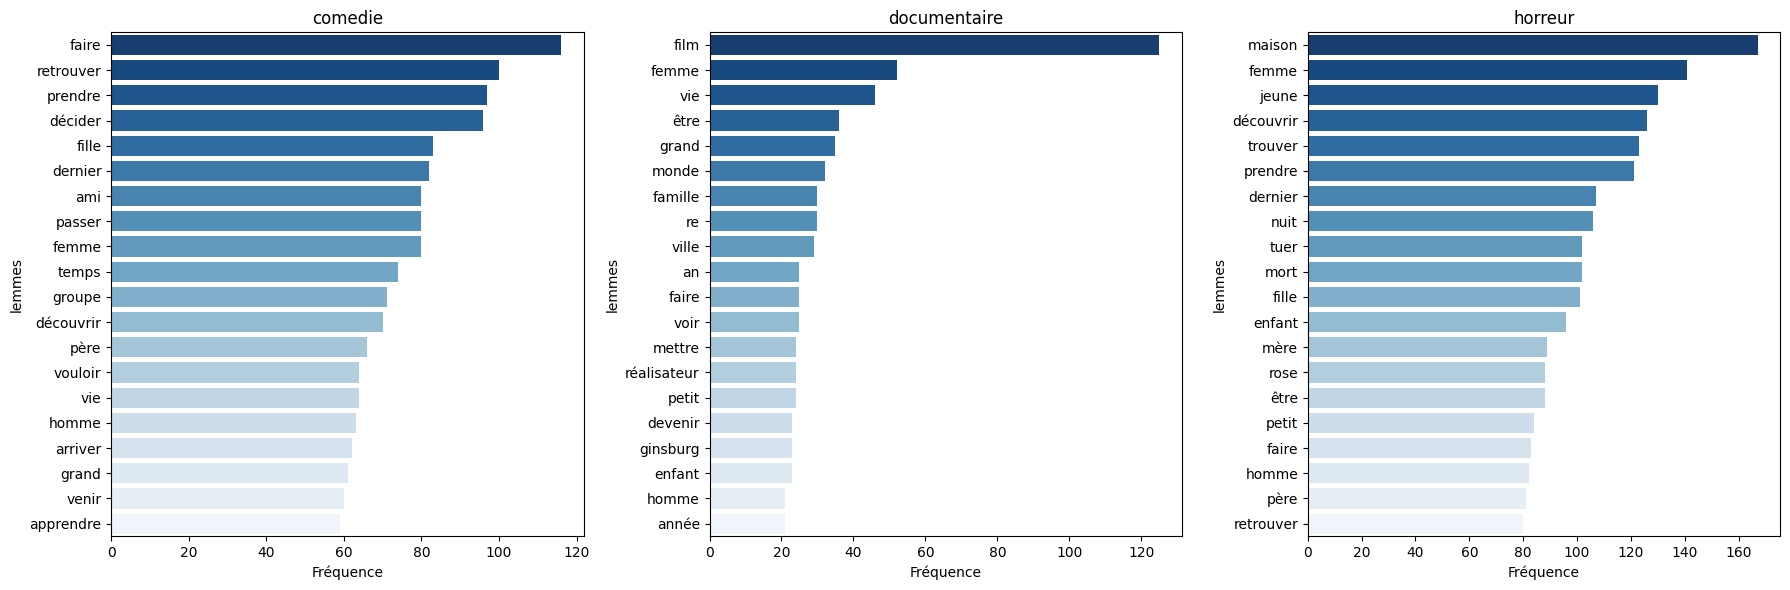

In [ ]:
# Visualisation
def freq_tokens_by_genre(freq_tokens, col, top_k):
    """Trace les tokens les plus fréquents par genre"""

    # Extraire les genres
    genres = freq_tokens["genre"].unique()
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(genres),
        figsize=(6 * len(genres), 6)
    )

    # Tracer le graphique
    for ax, genre in zip(axes, genres):
        df_genre = (
            freq_tokens[freq_tokens["genre"] == genre]
            .sort_values("frequence", ascending=False)
            .head(top_k)
        )

        sns.barplot(
            data=df_genre,
            x="frequence",
            y=col,
            ax=ax,
            palette="Blues_r",
            hue=col,
            legend=False
        )

        ax.set_title(genre)
        ax.set_xlabel("Fréquence")
        ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()

freq_tokens_by_genre(most_freq_lemmas, col="lemmes", top_k=20)

Le graphique ci-dessus présente les mots les plus fréquents dans les synopsis des 3 genres de notre corpus. Cette représentation peut par exemple nous permettre de constater que les films d'horreur semblent souvent se dérouler dans une maison puisqu'il s'agit du mot le plus fréquent. On retrouve également des mots comme _nuit_, _mort_, _tuer_, etc.

Une autre représentations, souvent très appréciée pour représenter les mots les plus fréquents d'un corpus ou d'un sous-corpus, est le **nuage de mots**. Il s'agit d'une représentation visuelle où les mots les plus fréquents sont regroupés, et dont la taille dépend de leur fréquence. Le module python `wordcloud` permet de tracer le nuage de mots d'un texte

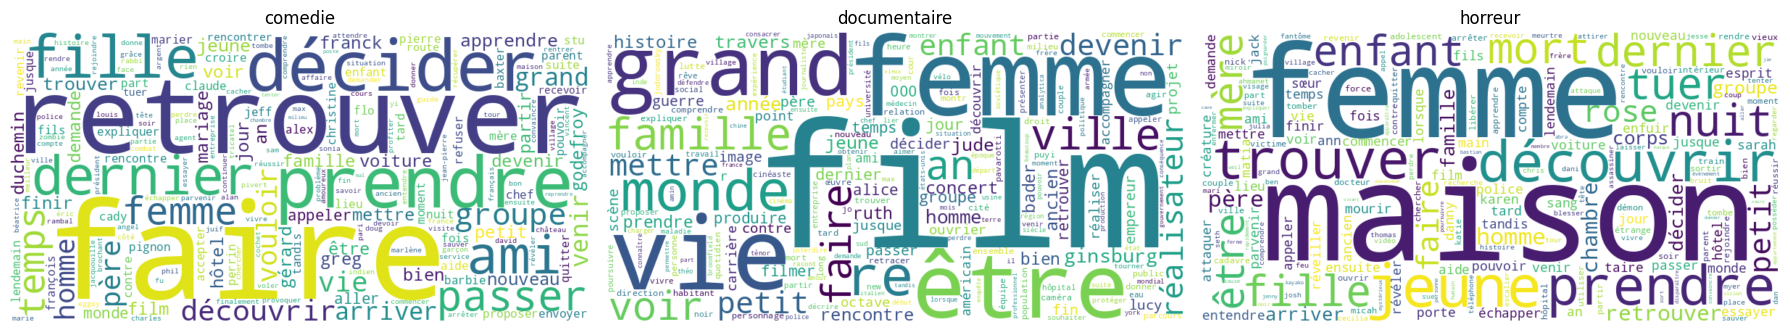

In [ ]:
# Nuages de mots

def wordcloud_by_genre(corpus, col):
    """Trace les nuages de mots par genre à partir d'un DataFrame"""

    # Extraire les genres
    genres = corpus["genre"].unique()
    n = len(genres)

    # Mettre les 3 nuages dans une même figure (optionnel)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    for ax, genre in zip(axes, genres):

        # Fréquence des mots delon les genres
        sub = corpus[corpus["genre"] == genre]
        freq_dict = dict(zip(sub[col], sub["frequence"]))

        # Tracer le nuage de mots
        wc = WordCloud(
            width=800,
            height=400,
            background_color="white",
            colormap="viridis"
        ).generate_from_frequencies(freq_dict)

        # Affichage
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(genre)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

wordcloud_by_genre(most_freq_lemmas, "lemmes")

**Remarque :** Ci-dessus on a tracé le nuage de mots à partir des textes lemmatisés et auxquels on a supprimé la ponctuation et les stopwords. Il est également possible de le faire à partir des textes bruts.

Alors pourquoi ce nettoyage ?

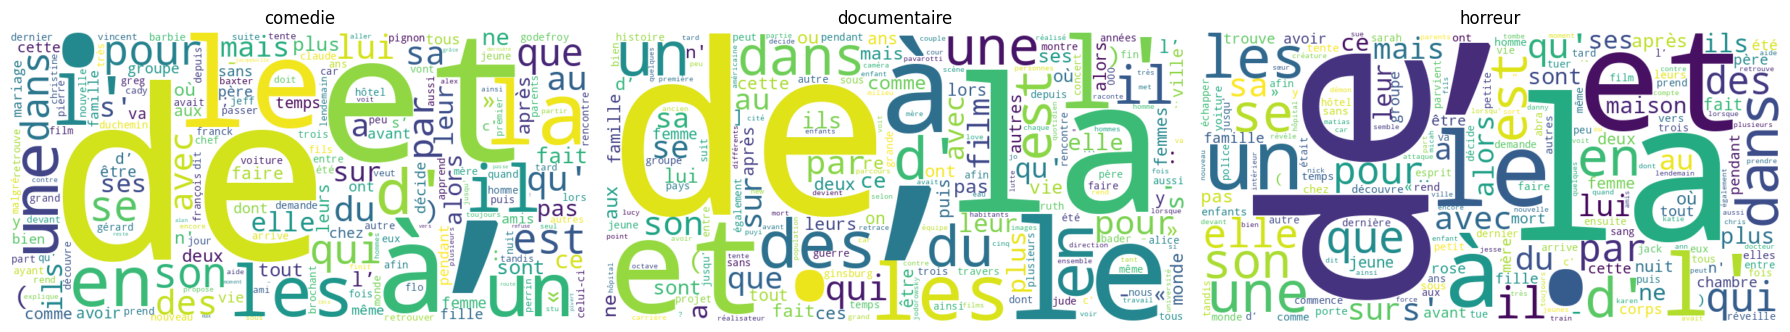

In [ ]:
# Simple tokenisation des textes
def get_tokens(text):
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        if token.text.strip() != '':
            tokens.append(token.text)
    return tokens

corpus["tokens"] = corpus["texte"].astype(str).apply(get_tokens)

# Comptage du nombre d'apparitions des tokens pour chaque genre
most_freq_tokens = count_occ_by_genre(corpus, col="tokens")

# Nuages de mots
wordcloud_by_genre(most_freq_tokens, "tokens")

La raison apparaît tout de suite lorsuq'on trace les nuages de mots sans nettoyage au préalable : les mots les plus fréquents sont les **_stopwords_** !

On ne peut donc pas tirer de conclusions de ces représentations visuelles. C'est pourquoi le **nettoyage** des textes est une étape primordiale pour leur utilisation dans des analyses plus complexes !

- **Verbes les plus fréquents par genre**

On a vu que le comptage des mots les plus fréquents dans un corpus peut permettre d'obtenir un aperçu des thèmes abordés dans les textes. On peut faire la même chose pour une catégorie morphosyntaxique en particulier. On peut par exemple vouloir analyser les verbes ou les adjectifs les plus fréquents en fonction des genres.

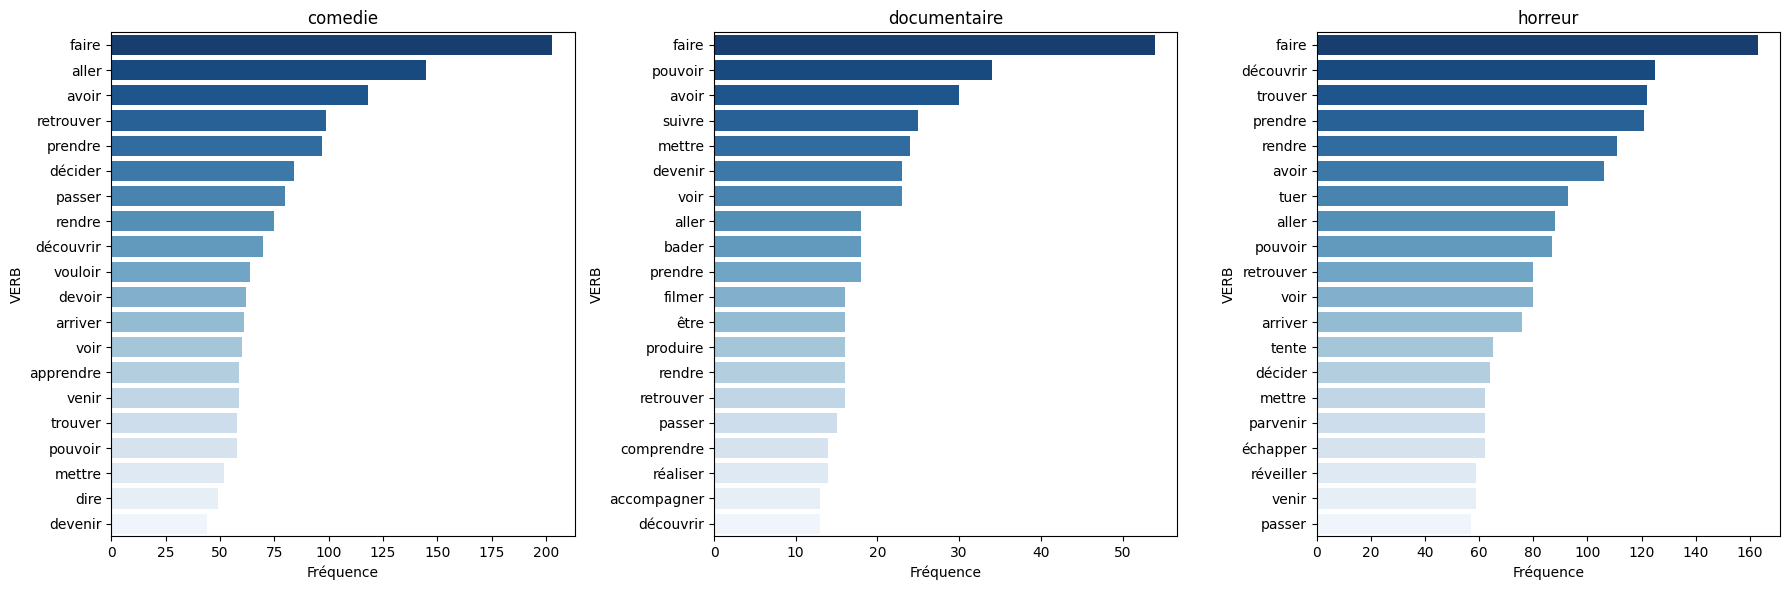

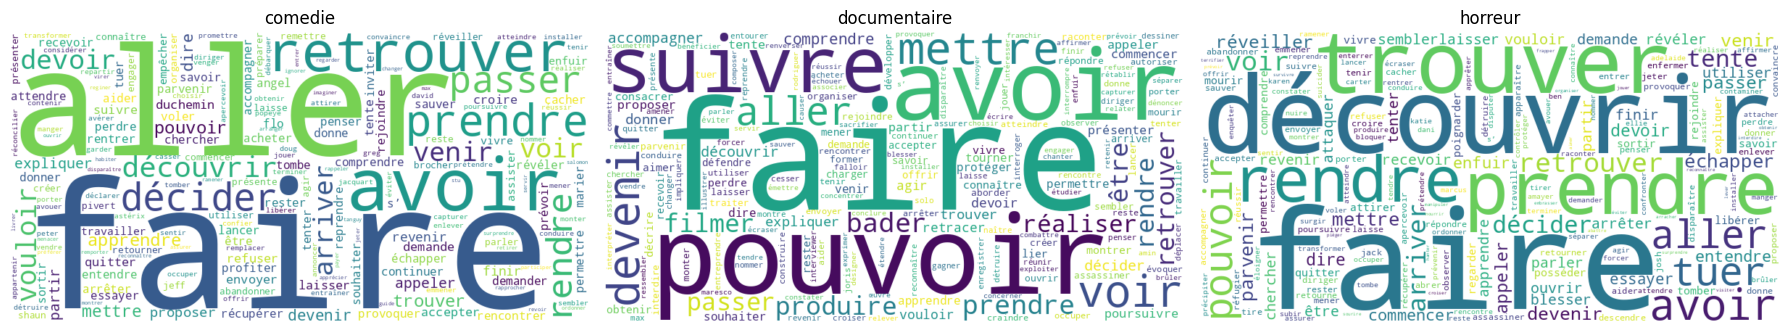

In [ ]:
# Catégorie morphosyntaxique que l'on veut étudier
target_pos = "VERB"

# Extraire les lemmes correspondant à la POS choisie
def get_tokens_by_pos(text, pos_tag):
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        if token.pos_ == pos_tag and token.lemma_.strip() != "":
            tokens.append(token.lemma_)
    return tokens

corpus[target_pos] = corpus["texte"].astype(str).apply(lambda x: get_tokens_by_pos(x, target_pos))

# Compter le nombre d'apparitions des lemmes pour chaque genre
most_freq_target_pos = count_occ_by_genre(corpus, col=target_pos)

# Visualisations
freq_tokens_by_genre(most_freq_target_pos, col=target_pos, top_k=20)   # Graphiques
wordcloud_by_genre(most_freq_target_pos, target_pos)                   # Nuages de mots

- **Prétraitement de données textuelles pour apprentissage automatique**

En bref, spaCy permet d'effectuer des tâches de _distant reading_ complètement personnalisables en fonction de ce l'on souhaite étudier.

Mais son utilisation peut aller bien au-delà de "simples" tâches d'analyses textuelles. On peut par exemple l'utiliser pour le prétraitement de données textuelles pour l'**entraînement** de modèles de classification.

Prenons le cas de notre corpus de synopsis de films, et entraînons

- un premier modèle de classification sans aucun pré-traitement sur nos textes
- un second modèle avec un pré-traitement avec spaCy.

In [ ]:
# Importation des librairies
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Séparation du corpus en ensembles d'entraînement et d'évaluation
X = corpus["texte"].astype(str)
y = corpus["genre"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Définition du modèle de classification
model = Pipeline([
    ("vect", TfidfVectorizer(ngram_range=(1,1))),
    ("clf", LogisticRegression())
])

a) Entraînement sur les données brutes

In [ ]:
# Enraînement du modèle sur les données brutes
model.fit(X_train, y_train)
pred = model.predict(X_test)

# Résultats
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

     comedie       0.75      0.75      0.75        20
documentaire       0.77      0.77      0.77        22
     horreur       0.60      0.60      0.60        20

    accuracy                           0.71        62
   macro avg       0.71      0.71      0.71        62
weighted avg       0.71      0.71      0.71        62



b) Entraînement sur les données nettoyées

In [ ]:
# Notre fonction de nettoyage des textes avec spaCy
def clean_text(text):
    doc = nlp(text.lower())
    lemmes = []
    for token in doc:
        if not token.is_stop and not token.is_punct and token.lemma_.strip() != '': # Suppression des stopwords et de la ponctuation
            lemmes.append(token.lemma_)                                             # Conservation des lemmes uniquement
    return " ".join(lemmes)

# Nettoyage des textes
X_train_cleaned = X_train.apply(clean_text)
X_test_cleaned = X_test.apply(clean_text)

# Enraînement du modèle sur les données nettoyées
model.fit(X_train_cleaned, y_train)
pred = model.predict(X_test_cleaned)

# Résultats
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

     comedie       0.79      0.75      0.77        20
documentaire       0.86      0.82      0.84        22
     horreur       0.73      0.80      0.76        20

    accuracy                           0.79        62
   macro avg       0.79      0.79      0.79        62
weighted avg       0.79      0.79      0.79        62



On observe une amélioration des résultats lorsque les données sont pré-traitées.

Mais il est important de préciser que ce n'est pas toujours le cas ! Cela dépend beaucoup de la tâche que l'on souhaite réaliser, de la quantité, du type et de la qualité de nos données, etc.

Toutefois, il est toujours bon de garder à l'esprit qu'un simple nettoyage avec spaCy peut jouer un rôle dans les données que l'on utilise pour l'entraînement d'un modèle.

### Conclusion

En conclusion, spaCy s'avère être une librairie utile pour de nombreuses tâches de **_distant reading_**. Malgré son utilisation qui requiert des bases en Python, cet outil offre l'avantage de pouvoir être implémenté de façon presque entièrement **personnalisable** pour des chaînes de traitement de texte, en fonction des besoins.

SpaCy offre ainsi la possibilité d'automatiser le traitement de très grand corpus, de visualiser des structures textuelles, et d'assurer une reproductibilté scientifique. Il permet de de **mesurer** et **quantifier** certaines analyses qualitatives, sans toutefois dispenser d'une expertise humaine.

### Ressources complémentaires

- Documentation de spaCy [🔗](https://spacy.io/usage)
- Un tuto de spaCy de Clément Plancq, Ingénieur à la MSH Val de Loire (UAR 3501) et au laboratoire Citeres (UMR 7324) [🔗](https://mate-shs.cnrs.fr/actions/tutomate/tuto44_python_spacy_clement_plancq/)
- Un autre tuto spaCy du Dr. W.J.B. Mattingly (Smithsonian Data Science Lab and United States Holocaust Memorial Museum) [🔗](https://spacy.pythonhumanities.com/01_02_linguistic_annotations.html)

- Un article sur l'analyse syntaxique en dépendances (SUD) [🔗](https://universaldependencies.org/udw18/PDFs/33_Paper.pdf)

- Vectorisation TF-IDF [🔗](https://fr.wikipedia.org/wiki/TF-IDF)